<a href="https://colab.research.google.com/github/rfortuna98/QNC-Fall-2025/blob/main/ex_phe_coc_fem_ch1%2B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== Data Preview ===
   Unnamed: 0  Animal Treatment  BodyMass  LeverPress  Unnamed: 5  Unnamed: 6  \
0         NaN      10    0ug/kg       390         117         NaN         NaN   
1         NaN      10    3ug/kg       385          23         NaN         NaN   
2         NaN      10   10ug/kg       385          16         NaN         NaN   
3         NaN      11    0ug/kg       285         100         NaN         NaN   
4         NaN      11    3ug/kg       290         115         NaN         NaN   

   Unnamed: 7  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  


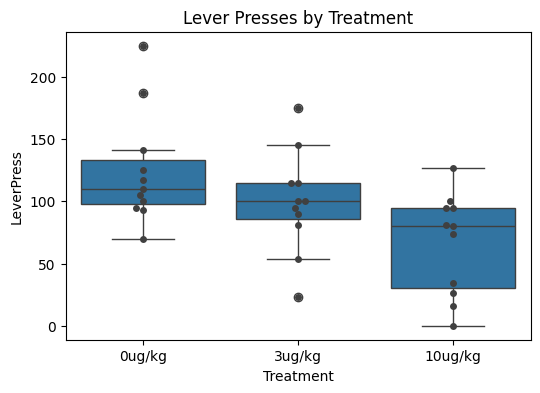

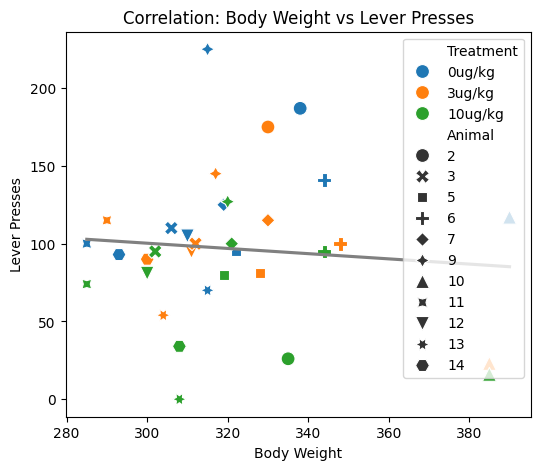


Pearson correlation: r = -0.09, p = 0.606


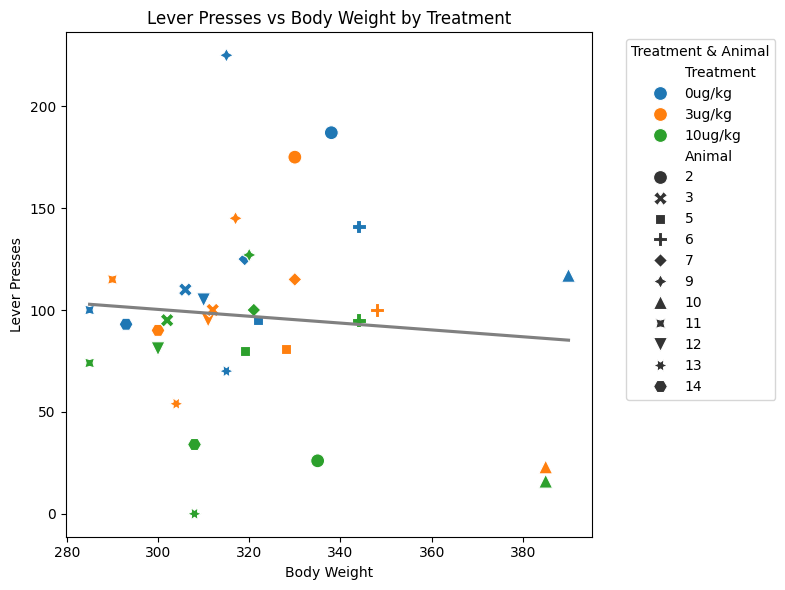

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# === Load data from CSV ===
# Replace 'data.csv' with your actual filename
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Book3.csv')

print("\n=== Data Preview ===")
print(df.head())

# === Box + Swarm Plot: Lever Presses by Treatment ===
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Treatment', y='LeverPress')
sns.swarmplot(data=df, x='Treatment', y='LeverPress', color=".25")
plt.title('Lever Presses by Treatment')
plt.show()

# === Scatter + Regression: Body Weight vs Lever Presses ===
plt.figure(figsize=(6,5))
sns.scatterplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    hue='Treatment',
    style='Animal',
    s=100
)
sns.regplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    scatter=False,
    ci=None,
    color='gray'
)
plt.title('Correlation: Body Weight vs Lever Presses')
plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.show()

# === Pearson Correlation ===
corr, p_value = pearsonr(df['BodyMass'], df['LeverPress'])
print(f"\nPearson correlation: r = {corr:.2f}, p = {p_value:.3f}")

# === Final Scatter (same as before, with legend styling) ===
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    hue='Treatment',
    style='Animal',
    s=100
)
sns.regplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    scatter=False,
    ci=None,
    color='gray'
)
plt.title('Lever Presses vs Body Weight by Treatment')
plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.legend(title='Treatment & Animal', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


=== Data Preview ===
   Unnamed: 0  Animal Treatment  BodyMass  LeverPress  Unnamed: 5  Unnamed: 6  \
0         NaN      10    0ug/kg       390         117         NaN         NaN   
1         NaN      10    3ug/kg       385          23         NaN         NaN   
2         NaN      10   10ug/kg       385          16         NaN         NaN   
3         NaN      11    0ug/kg       285         100         NaN         NaN   
4         NaN      11    3ug/kg       290         115         NaN         NaN   

   Unnamed: 7  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  


<Figure size 800x600 with 0 Axes>

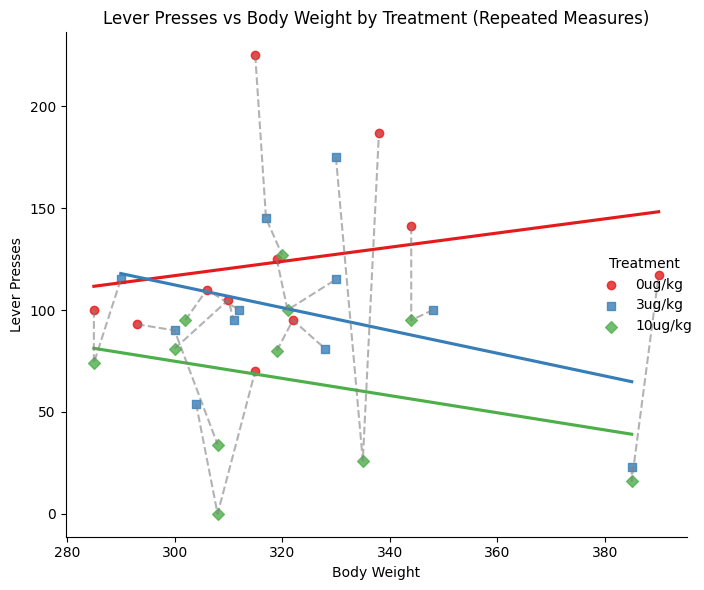

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load data from CSV ===
# Replace 'data.csv' with your actual file name or path
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Book3.csv')

print("\n=== Data Preview ===")
print(df.head())

# === Repeated-Measures Scatter Plot ===
plt.figure(figsize=(8,6))

# Scatter + regression lines per treatment
sns.lmplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    hue='Treatment',
    markers=['o', 's', 'D'],   # different marker shapes per treatment
    palette='Set1',
    ci=None,
    height=6,
    aspect=1
)

# Overlay repeated-measure lines for each animal
for animal in df['Animal'].unique():
    animal_data = df[df['Animal'] == animal].sort_values('BodyMass')
    plt.plot(
        animal_data['BodyMass'],
        animal_data['LeverPress'],
        color='gray',
        linestyle='--',
        alpha=0.6
    )

plt.title('Lever Presses vs Body Weight by Treatment (Repeated Measures)')
plt.xlabel('Body Weight')
plt.ylabel('Lever Presses')
plt.tight_layout()
plt.show()


=== Data Preview ===
   Unnamed: 0  Animal Treatment  BodyMass  LeverPress  Unnamed: 5  Unnamed: 6  \
0         NaN      10    0ug/kg       390         117         NaN         NaN   
1         NaN      10    3ug/kg       385          23         NaN         NaN   
2         NaN      10   10ug/kg       385          16         NaN         NaN   
3         NaN      11    0ug/kg       285         100         NaN         NaN   
4         NaN      11    3ug/kg       290         115         NaN         NaN   

   Unnamed: 7  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  


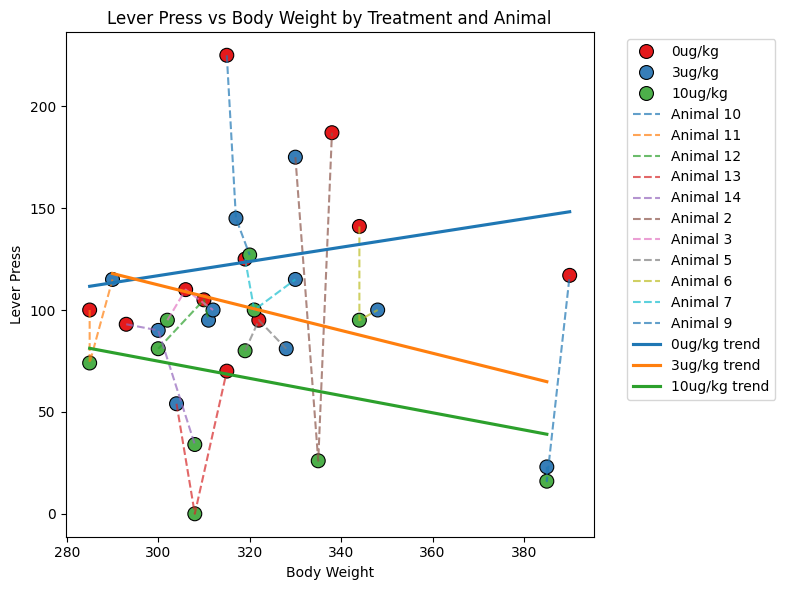

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load CSV data ===
# Replace 'data.csv' with your actual filename
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Book3.csv')

print("\n=== Data Preview ===")
print(df.head())

plt.figure(figsize=(8,6))

# === Scatter points: colored by Treatment ===
sns.scatterplot(
    data=df,
    x='BodyMass',
    y='LeverPress',
    hue='Treatment',
    palette='Set1',
    s=100,
    edgecolor='black',
    legend='full'
)

# === Connect repeated measures per Animal (colored by Animal) ===
animals = df['Animal'].unique()
palette_animals = sns.color_palette("tab10", len(animals))

for i, animal in enumerate(animals):
    animal_data = df[df['Animal'] == animal].sort_values('BodyMass')
    plt.plot(
        animal_data['BodyMass'],
        animal_data['LeverPress'],
        color=palette_animals[i],
        linestyle='--',
        alpha=0.7,
        label=f"Animal {animal}"
    )

# === Add separate regression lines per Treatment ===
for treatment in df['Treatment'].unique():
    treatment_data = df[df['Treatment'] == treatment]
    sns.regplot(
        data=treatment_data,
        x='BodyMass',
        y='LeverPress',
        scatter=False,
        ci=None,
        label=f"{treatment} trend",
        line_kws={'linestyle':'-'}
    )

plt.xlabel('Body Weight')
plt.ylabel('Lever Press')
plt.title('Lever Press vs Body Weight by Treatment and Animal')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [11]:
import pandas as pd
import numpy as np

# === Load data from CSV ===
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Book3.csv')

# Check which lever column exists
if 'LeverPress' in df.columns:
    lever_col = 'LeverPress'
elif 'Lever_Presses' in df.columns:
    lever_col = 'Lever_Presses'
else:
    raise KeyError("CSV must contain a 'LeverPress' or 'Lever_Presses' column.")

print("\n=== Data Preview ===")
print(df.head())

# === Create weight bins ===
bins = [280, 300, 320, 340, 360, 400]
labels = ['280–300', '300–320', '320–340', '340–360', '360–400']
df['Weight_Bin'] = pd.cut(df['BodyMass'], bins=bins, labels=labels)

# === Compute mean, variance, std, count per bin ===
variance_df = (
    df.groupby('Weight_Bin', observed=False)[lever_col]
      .agg(['mean', 'var', 'std', 'count'])
      .reset_index()
)

print("\n=== Lever Press Statistics by Body Weight Bin ===")
print(variance_df.round(2))


=== Data Preview ===
   Unnamed: 0  Animal Treatment  BodyMass  LeverPress  Unnamed: 5  Unnamed: 6  \
0         NaN      10    0ug/kg       390         117         NaN         NaN   
1         NaN      10    3ug/kg       385          23         NaN         NaN   
2         NaN      10   10ug/kg       385          16         NaN         NaN   
3         NaN      11    0ug/kg       285         100         NaN         NaN   
4         NaN      11    3ug/kg       290         115         NaN         NaN   

   Unnamed: 7  
0         NaN  
1         NaN  
2         NaN  
3         NaN  
4         NaN  

=== Lever Press Statistics by Body Weight Bin ===
  Weight_Bin    mean      var    std  count
0    280–300   92.17   208.57  14.44      6
1    300–320   97.50  2835.65  53.25     14
2    320–340  111.29  3064.90  55.36      7
3    340–360  112.00   637.00  25.24      3
4    360–400   52.00  3181.00  56.40      3


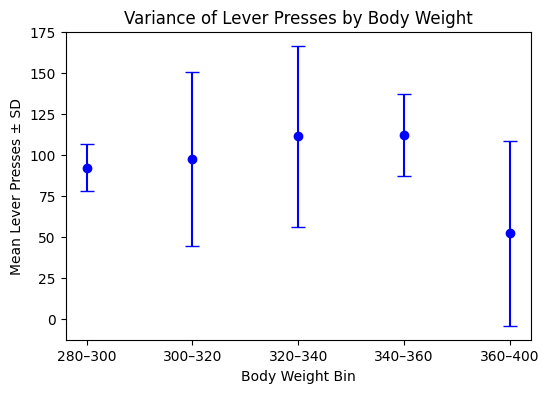

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.errorbar(
    variance_df['Weight_Bin'],
    variance_df['mean'],
    yerr=variance_df['std'],
    fmt='o',
    capsize=5,
    color='blue'
)
plt.xlabel('Body Weight Bin')
plt.ylabel('Mean Lever Presses ± SD')
plt.title('Variance of Lever Presses by Body Weight')
plt.show()

In [14]:
from scipy.stats import pearsonr, spearmanr

# Pearson correlation (linear relationship)
r, p = pearsonr(df['BodyMass'], df['LeverPress'])
print(f"Pearson correlation: r = {r:.2f}, p = {p:.3f}")

# Spearman correlation (monotonic relationship)
rho, p_s = spearmanr(df['BodyMass'], df['LeverPress'])
print(f"Spearman correlation: rho = {rho:.2f}, p = {p_s:.3f}")

Pearson correlation: r = -0.09, p = 0.606
Spearman correlation: rho = 0.16, p = 0.389


In [17]:
import statsmodels.api as sm

# Predictor (body weight)
X = df['BodyMass']
X = sm.add_constant(X)  # adds intercept
y = df['LeverPress']

# Fit linear regression
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             LeverPress   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.023
Method:                 Least Squares   F-statistic:                    0.2709
Date:                Mon, 03 Nov 2025   Prob (F-statistic):              0.606
Time:                        22:09:54   Log-Likelihood:                -173.59
No. Observations:                  33   AIC:                             351.2
Df Residuals:                      31   BIC:                             354.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        150.6094    104.037      1.448      0.1

In [19]:
import statsmodels.formula.api as smf

# Mixed-effects: Animal as random effect
model = smf.mixedlm("LeverPress ~ BodyMass", df, groups=df["Animal"])
result = model.fit()
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: LeverPress
No. Observations: 33      Method:             REML      
No. Groups:       11      Scale:              1630.0180 
Min. group size:  3       Log-Likelihood:     -169.3940 
Max. group size:  3       Converged:          Yes       
Mean group size:  3.0                                   
--------------------------------------------------------
           Coef.  Std.Err.   z    P>|z|  [0.025   0.975]
--------------------------------------------------------
Intercept 150.828  134.084  1.125 0.261 -111.971 413.627
BodyMass   -0.168    0.415 -0.406 0.685   -0.982   0.646
Group Var 776.670   18.193                              



In [20]:
import statsmodels.formula.api as smf

# Mixed-effects: Animal as random effect
model = smf.mixedlm("LeverPress ~ Animal", df, groups=df["BodyMass"])
result = model.fit()
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: LeverPress
No. Observations: 33      Method:             REML      
No. Groups:       25      Scale:              1463.1001 
Min. group size:  1       Log-Likelihood:     -166.5222 
Max. group size:  2       Converged:          Yes       
Mean group size:  1.3                                   
--------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025  0.975]
--------------------------------------------------------
Intercept   131.208   19.200  6.834 0.000 93.576 168.840
Animal       -4.102    2.099 -1.954 0.051 -8.215   0.012
Group Var   574.917   19.291                            

